# Data preprocessing

This notebook contains the code for preprocessing the data for the Random Forest analysis of factors influencing post-fire vegetation recovery in tropical peat forests in Indonesia. 

The notebook contains the following steps:
1. [Obtain Indonesia shapefile](#Indonesia-shapefile)
2. [Use MODIS fire alerts to identify study period](#MODIS-fire-alerts)
3. [Load burned area](#Burned-area)
4. [Set up pre-fire mean EVI and post-fire EVI timeseries](#EVI)

At the end, a NetCDF file containing all layers is exported for visualization. 

In [1]:
# General settings and important variables
# projection = 'EPSG:3857' # Web Mercator (in m) - preserves angles, but distorts distances and areas
equal_area_proj = 'EPSG:8857' # Equal Earth

# defined start and end of fire season we investigate
start_date = '2015-08-01'
end_date = '2015-10-31'

# Indonesia shapefile

In [2]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.pyplot as plt

# import country borders using natural earth data
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
world = gpd.read_file(shpfilename)

# select only Indonesia
indonesia = world[world['NAME'] == 'Indonesia']

# export
indonesia.to_file('output-data/indonesia.shp')

# reproject
# indonesia_reproj = indonesia.copy().to_crs('EPSG:3857')

[]

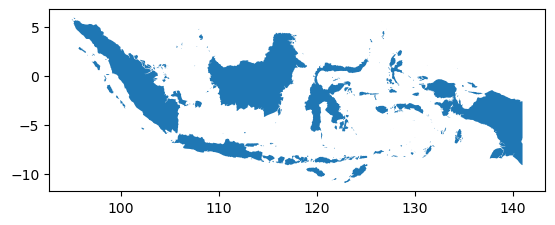

In [3]:
indonesia.plot()
plt.plot()

In [4]:
# get bounding box coordinates
indonesia.bounds

,minx,miny,maxx,maxy
0,95.012706,-10.922621,140.977627,5.910102


# MODIS fire alerts 
from NASA FIRMS

Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

$\rightarrow$ used to identify study period (which fire season) and as influencing factor (fire history)

In [3]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# read as geopandas dataframe
modis_fa_path = "input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"
modis_fa = gpd.read_file(modis_fa_path)

In [5]:
# filter to only keep TYPE 0 (presumed vegetation fire, not volcano activity etc.)
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0].copy()

In [6]:
# add column with year and month (as integers)
modis_fa_vf.loc[:,"YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

modis_fa_vf.loc[:,"MONTH"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=2).str[1].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

In [9]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,YEAR,MONTH
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),2001,1
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),2001,1
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),2001,1
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),2001,1
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),2001,1


Number of fire pixels in 2015: 2810394


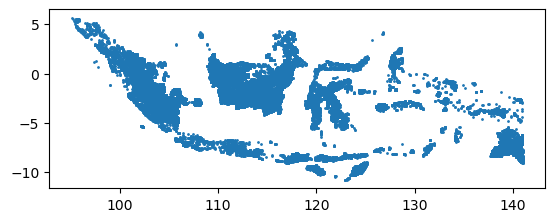

In [10]:
# plot fires in 2015
modis_fa_vf_2015 = modis_fa_vf[modis_fa_vf["YEAR"] == 2015]

print("Number of fire pixels in 2015:", end=' ')
print(modis_fa_vf_2015.size)

modis_fa_vf_2015.plot(markersize=1)
plt.show()

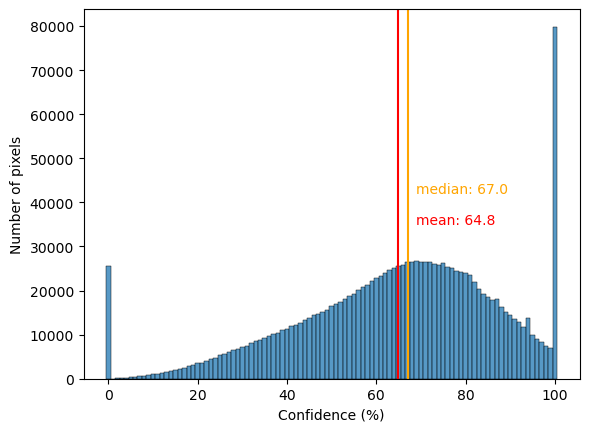

In [11]:
# check distribution of confidence
sns.histplot(x="CONFIDENCE", data=modis_fa_vf, discrete=True)
plt.ylabel("Number of pixels")
plt.xlabel("Confidence (%)")

# add mean confidence
mean_conf = modis_fa_vf.CONFIDENCE.mean()
plt.axvline(mean_conf, color="red")
plt.text(x=mean_conf+4, y=35000, s=f"mean: {round(mean_conf,1)}", color="red")

# add median confidence
med_conf = np.median(modis_fa_vf.CONFIDENCE)
plt.axvline(med_conf, color="orange")
plt.text(x=mean_conf+4, y=42000, s=f"median: {round(med_conf,1)}", color="orange")

plt.show()

In [12]:
np.std(modis_fa_vf.CONFIDENCE)

22.252626195361497

In [7]:
# add boolean column with confidence classification based on defined threshold
confidence_threshold = 85
modis_fa_vf['HIGH_CONFIDENCE'] = np.where(modis_fa_vf['CONFIDENCE'] >= confidence_threshold, True, False)

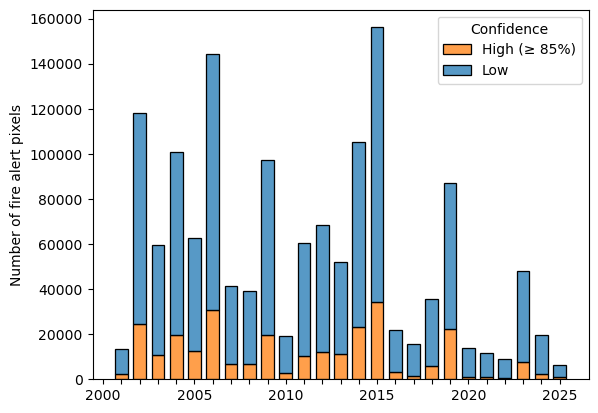

In [14]:
# check nr of fires per year
sns.histplot(x="YEAR", 
             hue="HIGH_CONFIDENCE", multiple="stack", 
             legend=False,
             data=modis_fa_vf,
             discrete=True,
             shrink=.7)

# adjust xticks
values = np.arange(2000,2026,1)
labels = np.arange(2000,2026,1)[::5] # only every fifth
labels = np.where(np.isin(values, labels), values, "")
plt.xticks(values, labels=labels)

plt.xlabel("")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

$\rightarrow$ 2015 was the year with the most fire alerts

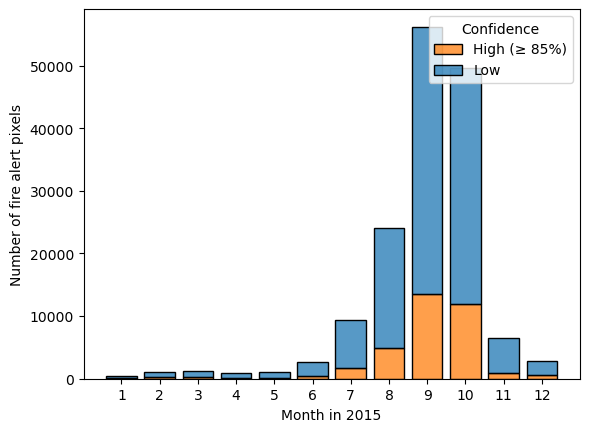

In [15]:
# check fires per month in 2015
modis_fa_2015 = modis_fa_vf[modis_fa_vf.YEAR == 2015]

sns.histplot(x="MONTH", 
             hue="HIGH_CONFIDENCE",
             multiple="stack", discrete=True,
             legend=False,
             shrink=.8,
             data=modis_fa_2015)

plt.xticks(np.arange(1,13,1))

plt.xlabel("Month in 2015")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

In [10]:
# keep only relevant columns
modis_fa_vf = modis_fa_vf[['LATITUDE', 'LONGITUDE', 'ACQ_DATE', 'CONFIDENCE', 'geometry', 'HIGH_CONFIDENCE']]

In [11]:
# subset to before, during, and after fire detection period (high confidence only)
# lower confidence threshold for after 2015 to make sure to exclude pixels with repeated burns

fires_before = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= confidence_threshold) & (modis_fa_vf.ACQ_DATE < start_date)]
fires_summer_2015 = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= confidence_threshold) & (modis_fa_vf.ACQ_DATE.between(start_date,end_date))]
fires_after = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= 50) & (modis_fa_vf.ACQ_DATE > end_date)]

In [14]:
# export 
fires_before.to_file('output-data/fire-alerts/fire_alerts_before.shp')
fires_after.to_file('output-data/fire-alerts/fire_alerts_after.shp')

/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_22374/3583540631.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fires_before.to_file('output-data/fire-alerts/fire_alerts_before.shp')
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ACQ_DATE created as String field, though DateTime requested.
  ogr_write(
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'HIGH_CONFIDENCE' to 'HIGH_CONFI'
  ogr_write(
/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_22374/3583540631.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fires_after.to_file('output-data/fire-alerts/fire_alerts_after.shp')
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ACQ_DATE creat

continued in [here](#Fire-history)

# Burned area

created with GEE (see script)
from https://developers.google.com/earth-engine/datasets/catalog/ESA_CCI_FireCCI_5_1

In [15]:
import rioxarray as rxr
import rasterio 
import numpy as np
from rasterio.enums import Resampling # for reprojection

In [16]:
filepath_ba = "input-data/burned-area/burned-area-aug-to-oct-2015.tif"
burned_area = rxr.open_rasterio(filepath_ba)

In [25]:
# adjust to reference grid
burned_area_reproj = burned_area.rio.reproject_match(evi_2year, resampling=Resampling.min) # only keep pixels where everything burned

# Peatlands

from Global Peatlands

In [17]:
import rioxarray as rxr
import xarray as xr
import rasterio 
import numpy as np

In [23]:
# load data as xarray
filepath_gp = "input-data/global-peatland-map/peatGPA22WGS_2cl.tif"
peatland = rxr.open_rasterio(filepath_gp)

# subset to Indonesia
peatland = peatland.sel(x=slice(indonesia.bounds.minx.item(),indonesia.bounds.maxx.item()), 
                        y=slice(indonesia.bounds.maxy.item(),indonesia.bounds.miny.item()))

In [29]:
# set 255 (no peatland) and 2 (peat in soil matrix) to NaN
peatland_only = peatland.where(peatland == 1, other=np.nan).astype('float32').drop_attrs()

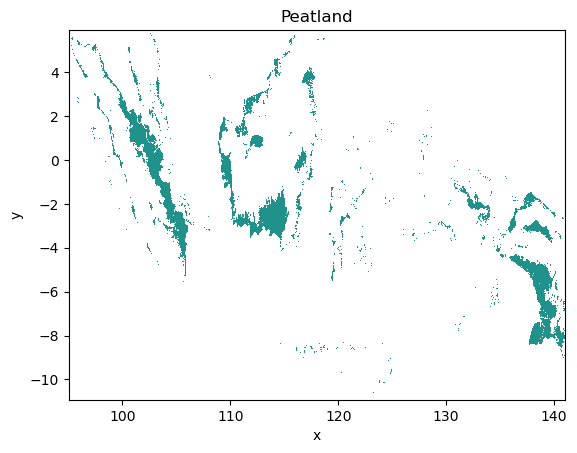

In [ ]:
peatland_only.plot(add_colorbar=False)
plt.title('Peatland')
plt.show()

In [24]:
# reproject to match burned area projection/resolution/grid
# peatland_only_reproj = peatland_only.rio.reproject_match(burned_area_reproj, resampling=Resampling.bilinear)

In [33]:
# export as tif and NetCDF
peatland_only.to_netcdf('output-data/peatland.nc')
peatland_only.rio.to_raster('output-data/peatland.tif')

In [25]:
# check where burned area and peatlands overlap

# merge both arrays
merged = xr.merge([burned_area_reproj.rename('burned_area'),
                   peatland_only_reproj.rename('peatland')],
                  compat='no_conflicts')

# add new column with category
categories = ['burned peatland', 'unburned peatland', 'burned other', 'other']
merged['category'] = xr.where((merged.burned_area == 1) & (merged.peatland == 1), 
                              1, 
                              xr.where((merged.burned_area == 0) & (merged.peatland == 1),
                                       2,
                                       xr.where((merged.burned_area == 1) & (merged.peatland != 1),
                                                3,
                                                4
                                               )))

In [26]:
# Area calculations

# reproject to equal area CRS - EPSG:8857 (Equal Earth) 
da = merged.category.astype(np.uint8)  # uint8 is perfect for small integer categories
da = da.rio.write_nodata(0)  # 0 is safe since your values are 1-4

categories_ea = da.rio.reproject('EPSG:8857', 
                                 resampling=Resampling.nearest,
                                 resolution=250) # set to 250x250m pixel size

categories_ea

<xarray.DataArray 'category' (band: 1, y: 9358, x: 17983)> Size: 168MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0]]], shape=(1, 9358, 17983), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 75kB 8.234e+05 8.232e+05 ... -1.516e+06 -1.516e+06
  * x            (x) float64 144kB 9.01e+06 9.011e+06 ... 1.351e+07 1.351e+07
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  0

In [27]:
# Get pixel dimensions in meters (Web Mercator units are meters)
res_x = float(abs(categories_ea.x[1] - categories_ea.x[0]))  # width of one pixel in meters
res_y = float(abs(categories_ea.y[1] - categories_ea.y[0]))  # height of one pixel in meters
pixel_area_m2 = res_x * res_y
pixel_area_km2 = pixel_area_m2 / 1e6

np.sqrt(pixel_area_m2)

np.float64(250.0)

In [28]:
# Count pixels per category
categories, counts = np.unique(
    categories_ea.values[~np.isnan(categories_ea.values)].astype(int),
    return_counts=True
)

area_df = pd.DataFrame({
    "category": categories,
    "pixel_count": counts,
    "area_km2": counts * pixel_area_km2,
    "area_ha": counts * pixel_area_km2 * 100
})

In [29]:
area_df

,category,pixel_count,area_km2,area_ha
0,0,3864083,2.415052e+05,2.415052e+07
1,1,221774,1.386088e+04,1.386088e+06
2,2,5759649,3.599781e+05,3.599781e+07
3,3,191575,1.197344e+04,1.197344e+06
4,4,158247833,9.890490e+06,9.890490e+08


In [30]:
print("Total burned area in Aug-Oct 2015 (ha)")
(1.386088e6 + 1.197344e6) / 1e6

Total burned area in Aug-Oct 2015 (ha)


2.583432

In [31]:
print("Total peatland area (ha)")
(1.386088e6 + 3.599781e7) / 1e6

Total peatland area (ha)


37.383898

In [32]:
print("Total burned peatland area (ha)")
1.386088e6 / 1e6

Total burned peatland area (ha)


1.386088

# EVI

used Google Earth Engine (script in repository) to compute yearly raster files containing the mean annual EVI,
obtained from MODIS 

In [1]:
import xarray as xr
import rioxarray as rxr
import glob

# get all relevant filepaths
files_2month = sorted(glob.glob("input-data/EVI/Landsat_MedianEVI_Jun_Jul*.tif"))
files_2year = sorted(glob.glob("input-data/EVI/Landsat_MedianEVI_2012_2015*.tif"))

In [2]:
evi_2year = xr.open_mfdataset(files_2year)
evi_2month = xr.open_mfdataset(files_2month)

In [47]:
da1 = evi_2month
da2 = evi_2year

same_grid = (
    da1.rio.transform() == da2.rio.transform() and
    da1.rio.shape == da2.rio.shape and
    da1.rio.crs == da2.rio.crs
)

In [48]:
same_grid

True

**executive decision**: the 2-year EVI is the reference raster for all others

In [ ]:
# save for easier computation later
xr.

# Fire history

In [36]:
import geopandas as gpd
import xarray as xr
import rioxarray
import numpy as np

# Extract coordinates from your dataset
lons = merged.x.values
lats = merged.y.values

# Compute pixel size (assumes regular grid)
dlon = abs(lons[1] - lons[0])
dlat = abs(lats[1] - lats[0])

# Get point coordinates
px = fires_before.geometry.x.values
py = fires_before.geometry.y.values

# Map each point to a pixel index
col_idx = np.floor((px - (lons[0] - dlon / 2)) / dlon).astype(int)
row_idx = np.floor(((lats[0] + dlat / 2) - py) / dlat).astype(int)

# Filter out points that fall outside the grid
valid = (
    (col_idx >= 0) & (col_idx < len(lons)) &
    (row_idx >= 0) & (row_idx < len(lats))
)
col_idx, row_idx = col_idx[valid], row_idx[valid]

# Count points per pixel
count_array = np.zeros((len(lats), len(lons)), dtype=int)
np.add.at(count_array, (row_idx, col_idx), 1)

# Add as a new variable to the dataset
merged["fire_alerts_before"] = xr.DataArray(
    count_array,
    dims=["y", "x"],
    coords={"y": merged.y, "x": merged.x},
)


In [37]:
# do the same for 

# Get point coordinates
px = fires_after.geometry.x.values
py = fires_after.geometry.y.values

# Map each point to a pixel index
col_idx = np.floor((px - (lons[0] - dlon / 2)) / dlon).astype(int)
row_idx = np.floor(((lats[0] + dlat / 2) - py) / dlat).astype(int)

# Filter out points that fall outside the grid
valid = (
    (col_idx >= 0) & (col_idx < len(lons)) &
    (row_idx >= 0) & (row_idx < len(lats))
)
col_idx, row_idx = col_idx[valid], row_idx[valid]

# Count points per pixel
count_array = np.zeros((len(lats), len(lons)), dtype=int)
np.add.at(count_array, (row_idx, col_idx), 1)

# Add as a new variable to the dataset
merged["fire_alerts_after"] = xr.DataArray(
    count_array,
    dims=["y", "x"],
    coords={"y": merged.y, "x": merged.x},
)

In [38]:
# Check burned area 2015 that burned again vs. did not
merged['burned_again'] = xr.where((merged.burned_area == 1) & (merged.fire_alerts_after >= 1),
                                  1,
                                  xr.where((merged.burned_area == 1) & (merged.fire_alerts_after == 0),
                                           0,
                                           np.nan)
                                 )

In [39]:
merged['study_area'] = xr.where(merged.burned_again == 0, 1, np.nan)

merged['study_area'] = merged['study_area'].rio.write_crs(merged.rio.crs)

In [40]:
study_area = merged['study_area'].rio.reproject('EPSG:4326', resampling=Resampling.bilinear)

In [41]:
study_area

<xarray.DataArray 'study_area' (band: 1, y: 8129, x: 20468)> Size: 1GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 8129, 20468))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 65kB 6.415 6.413 6.411 ... -11.83 -11.84 -11.84
  * x            (x) float64 164kB 95.01 95.02 95.02 95.02 ... 141.0 141.0 141.0
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

In [42]:
study_area.to_netcdf('study_area.nc')

# Land cover 2015

from Global Landcover map 2015 by Li et al. (2023)

In [5]:
import xarray as xr
import rioxarray as rxr
import numpy as np
import os
from rioxarray.merge import merge_arrays
import geopandas as gpd

# extract relevant file names by coordinates
file_names = []
for e_coord in np.arange(92, 145, 4):
    for suffix in ['2N', '2S', '6S', '10S', '14S']:
        file_name = f'GLC-2015_{e_coord}E_{suffix}'
        path = f'input-data/land-cover/{file_name}.tif'
        if os.path.exists(path):
            file_names.append(path)

# open files
arrays = [
    rxr.open_rasterio(f, chunks="auto")
    for f in file_names
]

# crop to Indonesia extent
indonesia = gpd.read_file("output-data/indonesia.shp")
minx, miny, maxx, maxy = indonesia.total_bounds
cropped_arrays = []
for arr in arrays:
    try:
        # keep only the part of each tile that intersects with the Indonesia bounding box
        cropped = arr.rio.clip_box(
            minx=minx,
            miny=miny,
            maxx=maxx,
            maxy=maxy
        )
        cropped_arrays.append(cropped)
    except Exception:
        # tile does not intersect study area → skip
        continue

# create binary mask (1 == forest area)
forest_code = 20
binary_arrays = [
    xr.where(arr == forest_code, 1, 0).astype("uint8")
    for arr in cropped_arrays
]

# ascribe CRS for faster merging
binary_arrays = [
    arr.rio.write_crs('EPSG:4326')
    for arr in binary_arrays
]

# merge into one xarray layer
forest_2015 = merge_arrays(binary_arrays)

In [31]:
# export as tif and NetCDF
forest_2015 = forest_2015.squeeze('band', drop=True) # remove unused dimension
forest_2015 = forest_2015.rename("forest_cover_2015") # set name
forest_2015.to_netcdf('output-data/forest_2015.nc', engine='netcdf4')
forest_2015.rio.to_raster('output-data/forest_2015.tif')

In [32]:
forest = rioxarray.open_rasterio('output-data/forest_2015.tif')
forest

<xarray.DataArray (band: 1, y: 67333, x: 183861)> Size: 12GB
[12379912713 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 539kB 5.91 5.91 5.91 5.909 ... -10.92 -10.92 -10.92
  * x            (x) float64 1MB 95.01 95.01 95.01 95.01 ... 141.0 141.0 141.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      forest_cover_2015

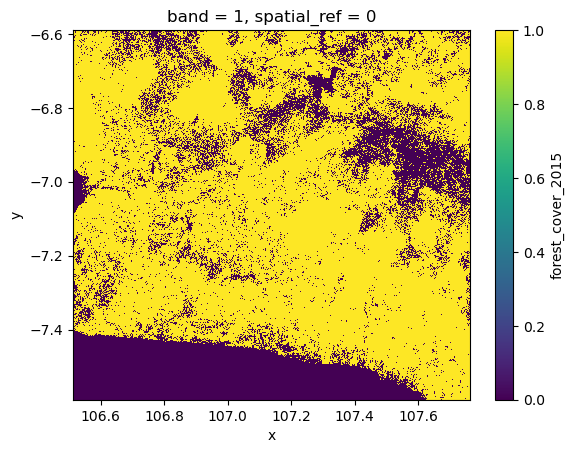

In [40]:
# example visualization
forest.isel(x=slice(46000,51000), y=slice(50000,54000)).plot()

# Land cover 2021

from ESA WorldCover V2 2021

$\rightarrow$ to filter out areas that were converted to cropland

In [3]:
import rioxarray as rxr
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window
import numpy as np
from pathlib import Path

due to size of data, first build virtual raster of land cover tiles using bash:

In [14]:
!gdalbuildvrt input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt $(find input-data/ESA_IndonesiaCover -name "*.tif")

0...10...20...30...40...50...60...70...80...90...100 - done.


In [4]:
import rioxarray as rxr
from rasterio.enums import Resampling

# Open your VRT lazily
landcover_10m = rxr.open_rasterio(
    "input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt",
    chunks={"x": 1024, "y": 1024}
)

# Binary mask
cropland_binary = (landcover_10m == 40).astype("uint8")

In [13]:
cropland_binary.isel(x=slice(0, 10000), y=slice(0,10000))

<xarray.DataArray (band: 1, y: 10000, x: 10000)> Size: 100MB
dask.array<getitem, shape=(1, 10000, 10000), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 80kB 6.0 6.0 6.0 6.0 ... 5.167 5.167 5.167 5.167
  * x            (x) float64 80kB 93.0 93.0 93.0 93.0 ... 93.83 93.83 93.83
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0
    scale_factor:  1.0
    add_offset:    0.0

In [ ]:
reproject_match

In [20]:
example

<xarray.DataArray (band: 1, y: 10000, x: 10000)> Size: 100MB
dask.array<getitem, shape=(1, 10000, 10000), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 80kB 6.0 6.0 6.0 6.0 ... 5.167 5.167 5.167 5.167
  * x            (x) float64 80kB 93.0 93.0 93.0 93.0 ... 93.83 93.83 93.83
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0
    scale_factor:  1.0
    add_offset:    0.0

In [21]:
evi_2year

<xarray.Dataset> Size: 46GB
Dimensions:      (band: 1, y: 67944, x: 170577)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 544kB 6.442 6.442 6.441 ... -11.87 -11.87 -11.87
  * x            (x) float64 1MB 95.01 95.01 95.01 95.01 ... 141.0 141.0 141.0
    spatial_ref  int64 8B 0
Data variables:
    band_data    (band, y, x) float32 46GB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [24]:
cropland_binary

<xarray.DataArray (band: 1, y: 216000, x: 612000)> Size: 132GB
dask.array<astype, shape=(1, 216000, 612000), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 2MB 6.0 6.0 6.0 6.0 6.0 ... -12.0 -12.0 -12.0 -12.0
  * x            (x) float64 5MB 93.0 93.0 93.0 93.0 ... 144.0 144.0 144.0 144.0
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0
    scale_factor:  1.0
    add_offset:    0.0

In [22]:
example = cropland_binary.isel(x=slice(0, 10000), y=slice(0,10000))

example.rio.reproject_match(
    evi_2year, # reference raster to align with (30 m, EPSG:4326)
    nodata=0,
    resampling=Resampling.max)


<xarray.DataArray (band: 1, y: 67944, x: 170577)> Size: 12GB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 67944, 170577), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 544kB 6.442 6.442 6.441 ... -11.87 -11.87 -11.87
  * x            (x) float64 1MB 95.01 95.01 95.01 95.01 ... 141.0 141.0 141.0
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    0

In [9]:
burned_area.rio.bbox

AttributeError: 'RasterArray' object has no attribute 'bbox'

In [5]:
# subset to burned area bounding box
cropland_binary

<xarray.DataArray (band: 1, y: 216000, x: 612000)> Size: 132GB
dask.array<astype, shape=(1, 216000, 612000), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 2MB 6.0 6.0 6.0 6.0 6.0 ... -12.0 -12.0 -12.0 -12.0
  * x            (x) float64 5MB 93.0 93.0 93.0 93.0 ... 144.0 144.0 144.0 144.0
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0
    scale_factor:  1.0
    add_offset:    0.0

In [ ]:
# Output path
out_path = "output-data/cropland_2021_30m.tif"

# Reproject to file on disk (blocks = memory safe)
cropland_binary.rio.reproject_match(
    evi_2year, # reference raster to align with (30 m, EPSG:4326)
    resampling=Resampling.max,
    dst_path=out_path
)

In [ ]:
cropland_30m = rxr.open_rasterio(out_path, chunks={"x": 1024, "y": 1024})

In [ ]:
import rioxarray as rxr
from rasterio.enums import Resampling

# open land cover VRT lazily with Dask chunks
landcover_10m = rxr.open_rasterio(
    "input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt",
    chunks={"x": 512, "y": 512}  # adjust depending on RAM
)

# convert to binary mask (40 = cropland)
cropland_binary = (landcover_10m == 40).astype("uint8")

# adjust resolution and align with EVI grid
cropland_2021 = cropland_binary.rio.reproject_match(
    evi_2year, # reference grid (30m resolution, EPSG:4326)
    resampling=Resampling.max  # max means: if any 10m pixel has value 1 (== cropland), the final 30m pixel will be 1
)


In [5]:
folder = Path('input-data/ESA_IndonesiaCover')
files = list(folder.rglob("*.tif"))

arrays = [
    rxr.open_rasterio(f, chunks={"x": 1024, "y": 1024})
    for f in files
]

binary_arrays = [
    xr.where(arr == 40, 1, 0).astype("uint8")
    for arr in arrays
]

# ascribe CRS (missing, but specified as EPSG 4326 in documentation)
binary_arrays = [
    arr.rio.write_crs('EPSG:4326')
    for arr in binary_arrays
]

merged_10m = merge_arrays(binary_arrays)

from rasterio.enums import Resampling
cropland_2021 = merged_10m.rio.reproject_match(
    evi_2year,
    resampling=Resampling.max
)

RasterioIOError: 43cf50ca-1fdf-42e8-996a-dbc1ec43884a.tif: Free disk space available is 17179869184 bytes, whereas 132192216000 are at least necessary. You can disable this check by defining the CHECK_DISK_FREE_SPACE configuration option to FALSE.

In [ ]:

folder = Path('input-data/ESA_IndonesiaCover')
files = list(folder.rglob("*.tif"))

# open files
arrays = [
    rxr.open_rasterio(f, chunks={"x": 2048, "y": 2048})
    for f in files
]

# create binary mask (40 == cropland)
cropland_code = 40
binary_arrays = [
    xr.where(arr == cropland_code, 1, 0).astype("uint8")
    for arr in arrays
]

# ascribe CRS for faster merging
binary_arrays = [
    arr.rio.write_crs('EPSG:4326')
    for arr in binary_arrays
]

# adjust resolution and align with EVI grid
aligned_30m = [
    arr.rio.reproject_match(
        evi_2year, # reference grid (30m resolution, EPSG:4326)
        resampling=rasterio.enums.Resampling.max # max means: if any 10m pixel has value 1 (== cropland), the final 30m pixel will be 1
    )
    for arr in binary_arrays
]

cropland_2021 = merge_arrays(aligned_30m)

In [38]:
binary_arrays[3].rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

# Merge layers

In [ ]:
# adjust all to grid (CRS and resolution) of Landsat data (EVI)

# Study area

In [ ]:
# burned dry season 2015
# did not burn after 2015
# peatland
# forest 2015
# forest 2021


# Export

In [42]:
# make sure all layers have the same projection
for var in merged_ds.data_vars:
    merged[var] = merged[var].rio.write_crs(merged.rio.crs)

merged.to_netcdf('output.nc')